# S&P 500 Survival Analysis

Analyzing which companies and sectors have survived longest in the S&P 500 index from 1975 to present.

## Dataset

- Source: S&P 500 Historical Constituents (Wikipedia + manual research)

- Period: 1975–2026

- Total records: ~906 companies

## Research Questions

1. Which sectors have the most companies surviving over 50 years?

2. Which crisis period had the most companies removed? (2000, 2008, 2020)

3. Which sectors have the highest removal rate?

## Data Limitations

- Companies added before 1975 have unknown exact entry dates — years_in_index is capped at 51.47 years

- GICS Sector data for some delisted companies may be incomplete (~12% filled manually)

In [194]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')

In [195]:
df = pd.read_csv('sp500_historical_constituents.csv')
df.columns = ['symbol', 'security', 'sector', 'date_added', 'date_removed', 'reason']
df.head()

,symbol,security,sector,date_added,date_removed,reason
0,A,Agilent Technologies,Health Care,2000-06-05,Present,NaN
1,AA,Alcoa,NaN,NaN,2016-01-01,AA spins off ARNC
2,AAL,American Airlines Group,NaN,2015-01-01,2024-01-01,Market capitalization change.[29]
3,AAP,Advance Auto Parts,NaN,2015-01-01,2023-01-01,S&P 500 and S&P 100 constituent Johnson & John...
4,AAPL,Apple Inc.,Information Technology,1982-11-30,Present,NaN


In [196]:
# print(df[df['sector'].isna()]['symbol'].tolist())

In [197]:
for i, row in df[df['sector'].isna()].iterrows():
    try:
        info = yf.Ticker(row['symbol']).info
        sector = info.get('sector') or info.get('sectorKey', '')
        df.at[i, 'sector'] = sector
        # print(f'{i}/{df['sector'].isna().value_counts()}')
    except:
        pass

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ALTR"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ANSS"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BIG"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: CMA"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: COG"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DAY"}}}
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DNB"}}}
ERROR:yfina

In [198]:
with open('manual_sector.json') as f:
    manual_sector = json.load(f)

In [199]:
manual_sector

{'ACAS': 'Financials',
 'ACE': 'Financials',
 'AET': 'Health Care',
 'AGN': 'Health Care',
 'ANDV': 'Energy',
 'APOL': 'Consumer Discretionary',
 'BBBY': 'Consumer Discretionary',
 'BCR': 'Health Care',
 'BHI': 'Energy',
 'BIG': 'Consumer Discretionary',
 'BJS': 'Energy',
 'BMC': 'Information Technology',
 'BRCM': 'Information Technology',
 'BS': 'Materials',
 'CA': 'Information Technology',
 'CAM': 'Energy',
 'CDAY': 'Industrials',
 'CTLT': 'Health Care',
 'BMS': 'Materials',
 'FRC': 'Financials',
 'MXIM': 'Information Technology',
 'WCG': 'Health Care',
 'FLT': 'Financials',
 'HFC': 'Energy',
 'TWTR': 'Communication Services',
 'ABMD': 'Health Care',
 'SIVB': 'Financials',
 'DWDP': 'Materials',
 'DRE': 'Real Estate',
 'ANSS': 'Information Technology',
 'RE': 'Financials',
 'INFO': 'Financials',
 'DISH': 'Communication Services',
 'EVHC': 'Health Care',
 'ARNC': 'Materials',
 'FBHS': 'Industrials',
 'FL': 'Consumer Discretionary',
 'CXO': 'Energy',
 'WLTW': 'Financials',
 'CSRA': 'Inf

In [220]:
df['sector'] = df.apply(
    lambda row: manual_sector.get(row['symbol'], row['sector']) if row['sector'] == '' or (pd.isna(row['sector'])) else row['sector'],
    axis=1
)
print(df['sector'].isna().sum())

0


In [201]:
print((df['sector'] == '').value_counts())
# print(df[df['sector'] == ''])

sector
False    907
Name: count, dtype: int64


In [202]:
sector_map = {
    'Healthcare': 'Health Care',
    'Financial Services': 'Financials',
    'Technology': 'Information Technology',
    'Consumer Cyclical': 'Consumer Discretionary',
    'Basic Materials': 'Materials',
    'Consumer Defensive': 'Consumer Staples',
}

sector_abbr = {
    'Industrials': 'IND',
    'Information Technology': 'IT',
    'Financials': 'FIN',
    'Health Care': 'HC',
    'Consumer Discretionary': 'CD',
    'Energy': 'ENE',
    'Communication Services': 'CS',
    'Consumer Staples': 'CST',
    'Utilities': 'UTL',
    'Materials': 'MAT',
    'Real Estate': 'RE',
}

df['sector'] = df['sector'].replace(sector_map).replace(sector_abbr)
print(df['sector'].value_counts())

sector
IT     128
FIN    125
IND    118
CD     114
HC     107
ENE     63
CST     60
CS      58
MAT     51
UTL     44
RE      39
Name: count, dtype: int64


In [203]:
print('Shape:', df.shape)
print('\nDtype:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nSector counts:')
print(df['sector'].value_counts())

Shape: (907, 6)

Dtype:
symbol          object
security        object
sector          object
date_added      object
date_removed    object
reason          object
dtype: object

Missing values:
symbol            0
security          0
sector            0
date_added      253
date_removed     27
reason          503
dtype: int64

Sector counts:
sector
IT     128
FIN    125
IND    118
CD     114
HC     107
ENE     63
CST     60
CS      58
MAT     51
UTL     44
RE      39
Name: count, dtype: int64


In [204]:
# แปลง date
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['date_removed'] = pd.to_datetime(df['date_removed'], errors='coerce')
print('\nDtype:')
print(df.dtypes)


Dtype:
symbol                  object
security                object
sector                  object
date_added      datetime64[ns]
date_removed    datetime64[ns]
reason                  object
dtype: object


In [205]:
df['is_pre1975'] = df['date_added'].isna()
df['still_in_index'] = df['date_removed'].isna()

# เติมเป็นวันที่ข้อมูบเริ่มกับวันที่วิเคราะห์ข้อมูล
df['date_added'] = df['date_added'].fillna(pd.Timestamp('1975-01-01'))
df['date_removed'] = df['date_removed'].fillna(pd.Timestamp('2026-06-07'))

# คำนวนเวลาที่อยู่
df['years_in_index'] = ((df['date_removed'] - df['date_added']).dt.days / 365).round(2)
# เช็ค
print('\nis_pre1975:', df['is_pre1975'].value_counts().to_dict())
print('still_in_index:', df['still_in_index'].value_counts().to_dict())


is_pre1975: {False: 654, True: 253}
still_in_index: {True: 530, False: 377}


In [206]:
print(df['years_in_index'].sort_values())

362     0.00
348     0.00
346     0.00
327     0.02
844     0.08
       ...  
193    69.31
201    69.31
365    69.31
892    69.31
895    69.31
Name: years_in_index, Length: 907, dtype: float64


In [207]:
print(df[df['years_in_index'] == 0][['symbol', 'security', 'date_added', 'date_removed']].head(10))

    symbol         security date_added date_removed
346    FOX  Fox Corporation 2019-01-01   2019-01-01
348   FOXA  Fox Corporation 2019-01-01   2019-01-01
362    GAS   AGL Resources. 2011-01-01   2011-01-01


In [208]:
print(df[df['symbol'] == 'GAS'][['symbol','security', 'date_added', 'date_removed', 'years_in_index']])

    symbol        security date_added date_removed  years_in_index
361    GAS   AGL Resources 1975-01-01   2016-01-01           41.03
362    GAS  AGL Resources. 2011-01-01   2011-01-01            0.00


In [209]:
# drop ที่ซ้ำออก
df = df.drop(index=362)
print(df[df['symbol'] == 'GAS'][['symbol', 'date_added', 'date_removed', 'years_in_index']])

    symbol date_added date_removed  years_in_index
361    GAS 1975-01-01   2016-01-01           41.03


In [210]:
still_symbols = ['FOX', 'FOXA']

df.loc[df['symbol'].isin(still_symbols), 'date_removed'] = pd.Timestamp('2026-06-07')
df.loc[df['symbol'].isin(still_symbols), 'still_in_index'] = True

df.loc[df['symbol'] == 'GAS', 'date_removed'] = pd.Timestamp('2016-07-01')

df.loc[df['symbol'].isin(still_symbols),'years_in_index'] = ((df['date_removed'] - df['date_added']).dt.days / 365).round(2)


df['years_in_index'].sort_values()

,years_in_index
327,0.02
844,0.08
140,0.16
719,0.21
855,0.21
...,...
602,69.31
607,69.31
558,69.31
561,69.31


In [211]:
df['years_in_index'].sort_values()

,years_in_index
327,0.02
844,0.08
140,0.16
719,0.21
855,0.21
...,...
602,69.31
607,69.31
558,69.31
561,69.31


In [212]:
max_years = (pd.Timestamp('2026-06-07') - pd.Timestamp('1975-01-01')).days / 365
df['years_in_index'] = df['years_in_index'].clip(upper=max_years).round(2)

print(df['years_in_index'].max())

51.47


## Research Questions

1. Which sectors have the most companies surviving over 50 years?
2. Which crisis period had the most companies removed? (2000, 2008, 2020)
3. Which sectors have the highest removal rate?

## Data Limitations
- Companies added before 1975 have unknown exact entry dates — years_in_index is capped at 51.47 years
- GICS Sector data for some delisted companies may be incomplete (~12% filled manually)

## Q1: Which Sectors Have the Most Long-Surviving Companies? (50+ Years)

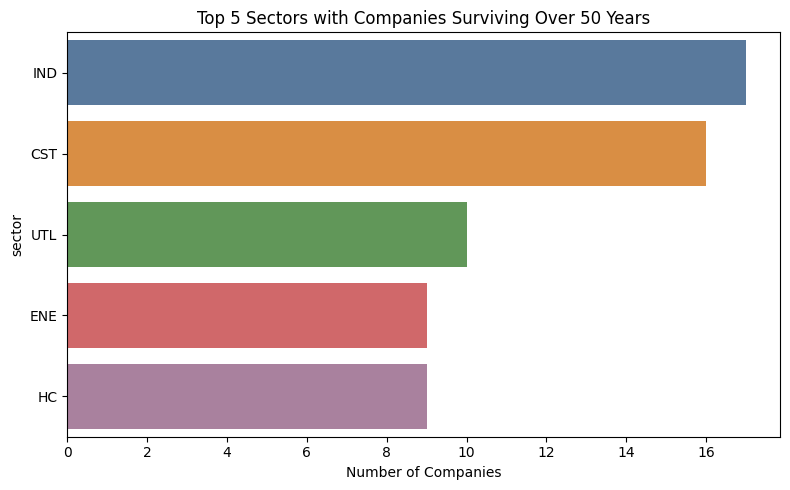

In [214]:
top5_sector = (df[df['years_in_index'] >= 50]
               .groupby('sector')
               .size()
               .sort_values(ascending=False)
               .head(5))

colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#B07AA1']

plt.figure(figsize=(8, 5))
sns.barplot(x=top5_sector.values, y=top5_sector.index, palette=colors)
plt.xlabel('Number of Companies')
plt.title('Top 5 Sectors with Companies Surviving Over 50 Years')
plt.tight_layout()
plt.show()

### Insight

Utilities and Consumer Staples dominate long-term survival, suggesting that companies providing essential services tend to remain in the index longer than growth-oriented sectors.

In [215]:
df['reason_clean'] = df['reason'].str.replace(r'\.\[\d+\].*', '', regex=True).str.strip()

top10_reason = (df['reason_clean'].dropna()
                .value_counts()
                .head(10))

print(top10_reason)

reason_clean
Market capitalization change                                                                                                                   96
Unknown missing removal                                                                                                                        27
Market capitalization changes                                                                                                                   7
Market capitalization change.[citation needed]                                                                                                  5
Market Cap changes.                                                                                                                             5
Capitalization rebalance                                                                                                                        3
WarnerMedia and Discovery merge to create Warner Bros. Discovery                                               

## Q2: Which Crisis Period Had the Most Companies Removed?

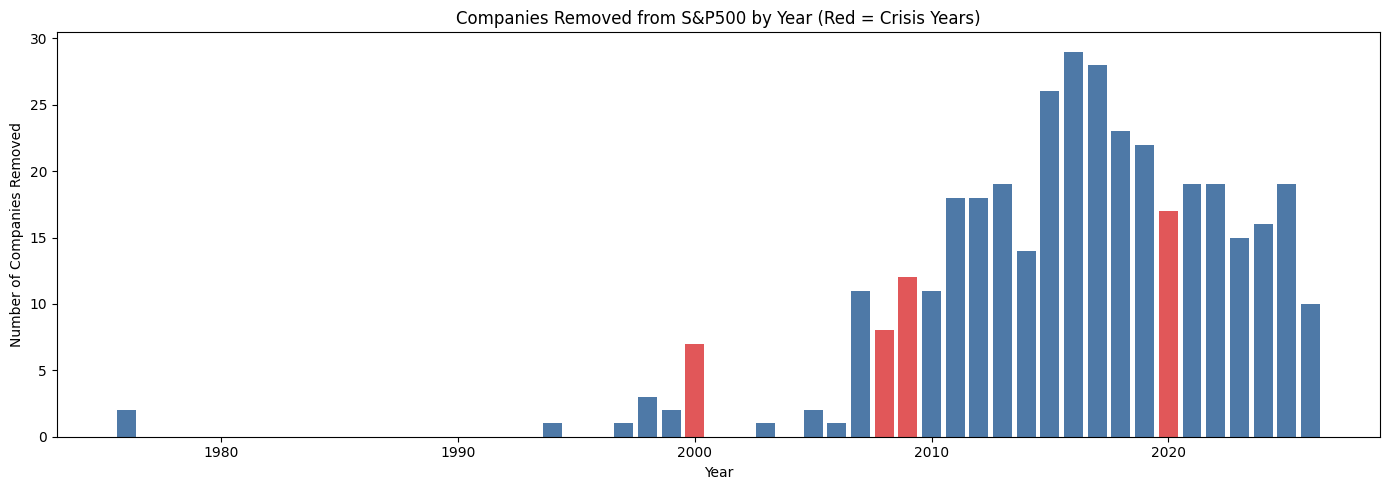

In [216]:
# กรองเฉพาะบ.ที่หลุดออกแล้ว
df_removed = df[df['still_in_index'] == False].copy()
df_removed['year_removed'] = df_removed['date_removed'].dt.year

# นับจำนวนที่หลุดออกแต่ละปี
removed_by_year = df_removed.groupby('year_removed').size()

# highlight วิกฤต
crisis_years = [2000, 2001, 2002, 2008, 2009, 2020]

colors = ['#E15759' if y in crisis_years else '#4E79A7'
          for y in removed_by_year.index]

plt.figure(figsize=(14, 5))
plt.bar(removed_by_year.index, removed_by_year.values, color=colors)
plt.xlabel('Year')
plt.ylabel('Number of Companies Removed')
plt.title('Companies Removed from S&P500 by Year (Red = Crisis Years)')
plt.tight_layout()
plt.show()

### Insight

The 2000–2002 Dot-com bubble and 2008 financial crisis show the highest removal spikes, reflecting how market downturns accelerate index reshuffling.

## Q3: Which Sectors Have the Highest Removal Rate?

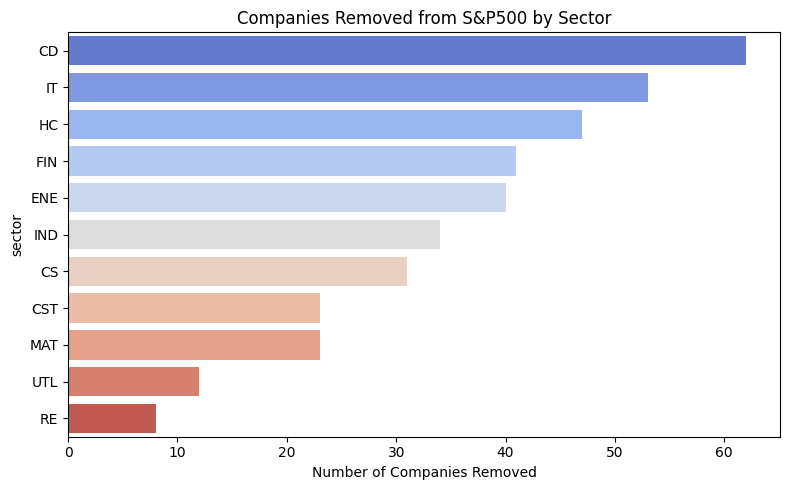

In [217]:
sector_removed = (df[df['still_in_index'] == False]
                  .groupby('sector')
                  .size()
                  .sort_values(ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x=sector_removed.values, y=sector_removed.index, palette='coolwarm')
plt.xlabel('Number of Companies Removed')
plt.title('Companies Removed from S&P500 by Sector')
plt.tight_layout()
plt.show()

### Insight

Financials and Industrials show the highest removal counts, while Utilities and Consumer Staples show relatively lower turnover — consistent with Q1 findings.

## Summary

Key findings from S&P 500 Survival Analysis (1975–2026):

1. **Utilities and Consumer Staples** have the highest proportion of companies surviving 50+ years

2. **2000–2002 and 2008** were the most disruptive periods, causing the highest number of removals

3. **Financials** had the highest total removal count, largely driven by the 2008 financial crisis

4. Companies providing **essential services** tend to outlast growth and cyclical sectors